=== 1. LOCALIZACIÓN Y CARGA DEL DATASET ===
✓ Cargando dataset desde: '..\Data_Sets\precio_consumidor_2026.csv'...
✓ Carga completada en 1.52 segundos.
Dimensiones: 221,432 filas x 15 columnas

=== 2. PIPELINE DE PREPROCESAMIENTO Y LIMPIEZA ===
Columnas de precio a procesar: ['Precio minimo', 'Precio maximo', 'Precio promedio']

✓ Dataset procesado exitosamente y guardado en: 'datos_consumidor_procesados.csv'
Dimensiones finales: 221,432 filas x 15 columnas

=== 3. PRUEBAS Y VALIDACIÓN TÉCNICA ===
✓ Todas las aserciones pasaron con éxito. Integridad de datos verificada.

=== 4. VISUALIZACIÓN DE DISPARIDAD Y ANÁLISIS DE MERCADO ===


C:\Users\crist\AppData\Local\Temp\ipykernel_10256\3407303498.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\crist\AppData\Local\Temp\ipykernel_10256\3407303498.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


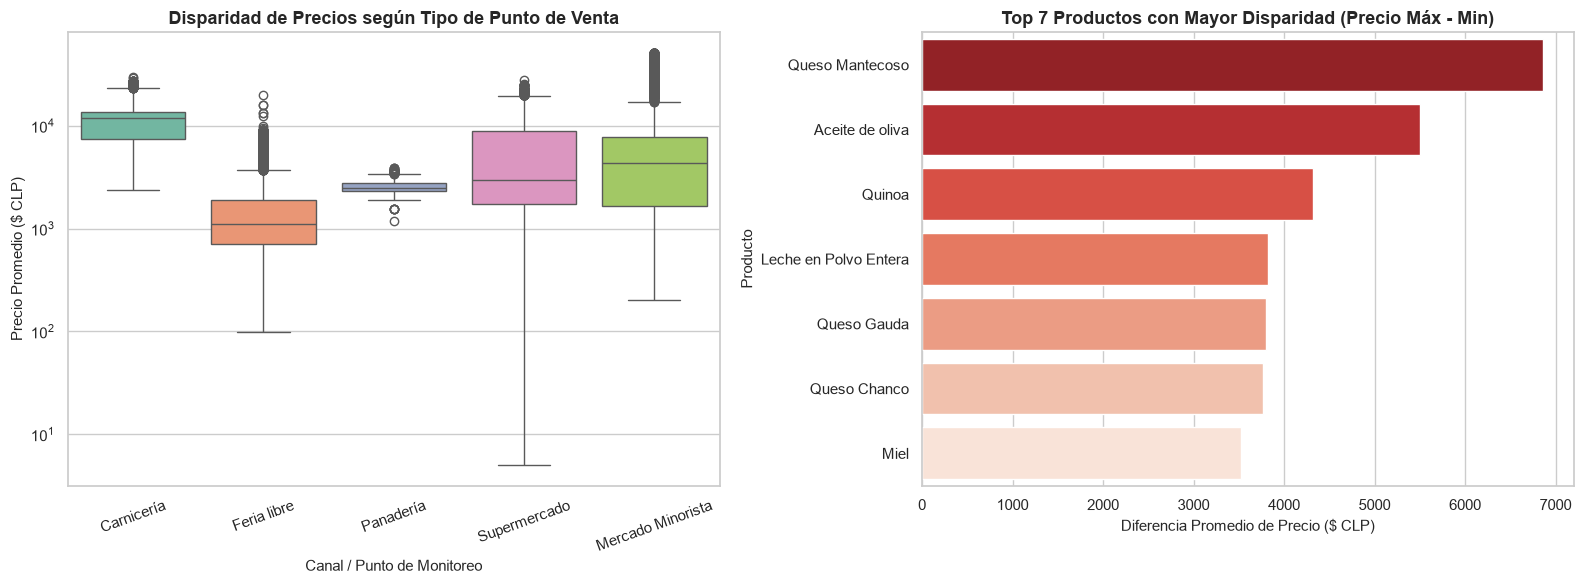

In [1]:
import os
import sys
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del entorno visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', None)

print("=== 1. LOCALIZACIÓN Y CARGA DEL DATASET ===")

ruta_csv = os.path.join("..", "Data_Sets", "precio_consumidor_2026.csv")

if not os.path.exists(ruta_csv):
    # Intentar rutas alternativas en caso de variación de nombre
    rutas_alt = ["precio_consumidor_2026.csv", os.path.join("Data_Sets", "precio_consumidor_2026.csv")]
    for r in rutas_alt:
        if os.path.exists(r):
            ruta_csv = r
            break

print(f"✓ Cargando dataset desde: '{ruta_csv}'...")
t_start = time.time()
df_raw = pd.read_csv(ruta_csv, low_memory=False)
t_load = time.time() - t_start

print(f"✓ Carga completada en {t_load:.2f} segundos.")
print(f"Dimensiones: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")

print("\n=== 2. PIPELINE DE PREPROCESAMIENTO Y LIMPIEZA ===")

def pipeline_limpieza_odepa(df_input):
    df = df_input.copy()
    
    # a. Normalización de textos y eliminación de espacios
    cols_texto = df.select_dtypes(include=['object', 'string']).columns
    for col in cols_texto:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace(['nan', 'NaN', 'NONE', 'NULL', ''], np.nan)
        
    # b. Identificar y limpiar columnas de precios (Manejo de formato chileno con coma decimal)
    cols_precio = ['Precio minimo', 'Precio maximo', 'Precio promedio']
    cols_precio_existentes = [c for c in cols_precio if c in df.columns]
    
    print(f"Columnas de precio a procesar: {cols_precio_existentes}")
    
    for col in cols_precio_existentes:
        # Reemplazar comas por puntos y eliminar caracteres no numéricos
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = df[col].str.replace(r'[^\d.]', '', regex=True)
        
        # Convertir a flotante numérico explícito
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Imputación de valores nulos con la mediana de la columna
        mediana_val = df[col].median()
        df[col] = df[col].fillna(mediana_val)
        
    # c. Tratamiento de Fechas (Fecha inicio y Fecha termino)
    for col_fecha in ['Fecha inicio', 'Fecha termino']:
        if col_fecha in df.columns:
            df[col_fecha] = pd.to_datetime(df[col_fecha], errors='coerce')
            
    # d. Imputación de variables categóricas
    for col in cols_texto:
        if col in df.columns and col not in cols_precio_existentes:
            df[col] = df[col].fillna("NO REGISTRADO")
            
    return df, cols_precio_existentes

# Ejecución del pipeline
df_clean, cols_precio_validas = pipeline_limpieza_odepa(df_raw)

# Guardar copia limpia en la carpeta F2
ruta_salida = "datos_consumidor_procesados.csv"
df_clean.to_csv(ruta_salida, index=False)
print(f"\n✓ Dataset procesado exitosamente y guardado en: '{ruta_salida}'")
print(f"Dimensiones finales: {df_clean.shape[0]:,} filas x {df_clean.shape[1]} columnas")

print("\n=== 3. PRUEBAS Y VALIDACIÓN TÉCNICA ===")
assert len(df_clean) > 0, "Error: El DataFrame procesado está vacío."
assert df_clean['Precio promedio'].dtype in [np.float64, np.float32], "Error: 'Precio promedio' no se convirtió a numérico."
assert df_clean['Precio promedio'].isnull().sum() == 0, "Error: Quedan valores nulos en 'Precio promedio'."
print("✓ Todas las aserciones pasaron con éxito. Integridad de datos verificada.")

print("\n=== 4. VISUALIZACIÓN DE DISPARIDAD Y ANÁLISIS DE MERCADO ===")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Comparación de precios promedio por Tipo de Punto de Monitoreo
top_puntos = df_clean['Tipo de punto monitoreo'].value_counts().head(5).index
df_top_puntos = df_clean[df_clean['Tipo de punto monitoreo'].isin(top_puntos)]

sns.boxplot(
    data=df_top_puntos, 
    x='Tipo de punto monitoreo', 
    y='Precio promedio', 
    ax=ax[0], 
    palette='Set2'
)
ax[0].set_title('Disparidad de Precios según Tipo de Punto de Venta', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Canal / Punto de Monitoreo', fontsize=11)
ax[0].set_ylabel('Precio Promedio ($ CLP)', fontsize=11)
ax[0].set_yscale('log') # Escala logarítmica para manejar la diferencia entre cortes de carne y otros productos
ax[0].tick_params(axis='x', rotation=20)

# Gráfico 2: Top 7 Productos con mayor variación / dispersión de precios
df_clean['Brecha_Precio'] = df_clean['Precio maximo'] - df_clean['Precio minimo']
top_brecha = df_clean.groupby('Producto')['Brecha_Precio'].mean().nlargest(7).reset_index()

sns.barplot(
    data=top_brecha, 
    x='Brecha_Precio', 
    y='Producto', 
    ax=ax[1], 
    palette='Reds_r'
)
ax[1].set_title('Top 7 Productos con Mayor Disparidad (Precio Máx - Min)', fontsize=13, fontweight='bold')
ax[1].set_xlabel('Diferencia Promedio de Precio ($ CLP)', fontsize=11)
ax[1].set_ylabel('Producto', fontsize=11)

plt.tight_layout()
plt.show()